In [1]:
# ============================================================
# Notebook 3
# Cell 1 - Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import geopandas as gpd
import rasterio
from rasterio.mask import mask

import matplotlib.pyplot as plt

print("="*70)
print("PRITHVIX - NOTEBOOK 3")
print("District-wise Feature Extraction")
print("="*70)

print("\nLibraries Imported Successfully.")

PRITHVIX - NOTEBOOK 3
District-wise Feature Extraction

Libraries Imported Successfully.


In [2]:
# ============================================================
# Cell 2 - Project Paths
# ============================================================

PROJECT_DIR = Path("/Users/rajdeepmandal/Desktop/PrithviX")

DATA_DIR = PROJECT_DIR / "Data"

BOUNDARY_DIR = DATA_DIR / "Boundaries"
RAINFALL_DIR = DATA_DIR / "Rainfall"
DEM_DIR = DATA_DIR / "DEM"
NDVI_DIR = DATA_DIR / "NDVI"
LANDCOVER_DIR = DATA_DIR / "LandCover"
SOIL_DIR = DATA_DIR / "Soil"
POPULATION_DIR = DATA_DIR / "Population"
LANDSLIDE_DIR = DATA_DIR / "LandslideInventory"
OSM_DIR = DATA_DIR / "OpenStreetMap"

OUTPUT_DIR = PROJECT_DIR / "Outputs"

OUTPUT_DIR.mkdir(exist_ok=True)

print("="*70)
print("PROJECT PATHS")
print("="*70)

print(PROJECT_DIR)

PROJECT PATHS
/Users/rajdeepmandal/Desktop/PrithviX


In [3]:
# ============================================================
# Cell 3 - Load District Boundaries
# ============================================================

boundary_file = next(BOUNDARY_DIR.glob("*.geojson"))

districts = gpd.read_file(boundary_file)

print("="*70)
print("BOUNDARY DATASET")
print("="*70)

print("Total Districts :", len(districts))
print("CRS :", districts.crs)

print("\nColumns:\n")
print(districts.columns.tolist())

display(districts.head())

BOUNDARY DATASET
Total Districts : 735
CRS : EPSG:4326

Columns:

['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Ashoknagar,,76128533B75548370501185,IND,ADM2,"POLYGON ((78.17491 24.84254, 78.17466 24.84194..."
1,Raisen,,76128533B57893545331548,IND,ADM2,"POLYGON ((77.38167 23.07004, 77.38094 23.0698,..."
2,Chhindwara,,76128533B70646408240587,IND,ADM2,"POLYGON ((79.23988 22.79135, 79.24 22.79172, 7..."
3,Betul,,76128533B82559220423608,IND,ADM2,"POLYGON ((78.27229 22.39973, 78.27169 22.39897..."
4,Hoshangabad,,76128533B45314020251888,IND,ADM2,"POLYGON ((78.03027 22.79953, 78.02986 22.79969..."


     shapeName shapeISO                  shapeID shapeGroup shapeType  \
0   Ashoknagar           76128533B75548370501185        IND      ADM2   
1       Raisen           76128533B57893545331548        IND      ADM2   
2   Chhindwara           76128533B70646408240587        IND      ADM2   
3        Betul           76128533B82559220423608        IND      ADM2   
4  Hoshangabad           76128533B45314020251888        IND      ADM2   

                                            geometry  
0  POLYGON ((78.17491 24.84254, 78.17466 24.84194...  
1  POLYGON ((77.38167 23.07004, 77.38094 23.0698,...  
2  POLYGON ((79.23988 22.79135, 79.24 22.79172, 7...  
3  POLYGON ((78.27229 22.39973, 78.27169 22.39897...  
4  POLYGON ((78.03027 22.79953, 78.02986 22.79969...  


<Figure size 1200x1200 with 0 Axes>

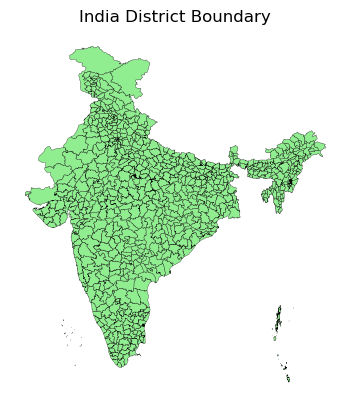

In [6]:
# ==========================================================
# Cell 4 — Plot India District Boundaries
# ==========================================================
import geopandas as gpd

boundary = gpd.read_file(
    DATA_DIR / "Boundaries" / "India_ADM2_GeoBoundaries_2025.geojson"
)

print(boundary.head())

import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

ax = boundary.plot(
    edgecolor="black",
    facecolor="lightgreen",
    linewidth=0.2
)

plt.title("India District Boundary")
plt.axis("off")
plt.show()

In [7]:
# ==========================================================
# Cell 5 — Rainfall Dataset
# ==========================================================

import pandas as pd

print("="*70)
print("RAINFALL DATASET")
print("="*70)

rain = pd.read_csv(
    RAINFALL_DIR / "Darjeeling.csv",
    skiprows=16
)

print("\nRows :", len(rain))
print("Columns :", len(rain.columns))

print("\nColumn Names:\n")
print(rain.columns.tolist())

print("\nFirst 5 Rows:\n")
display(rain.head())

print("\nStatistics:\n")
display(rain.describe())

RAINFALL DATASET

Rows : 4025
Columns : 10

Column Names:

['YEAR', 'DOY', 'ALLSKY_SFC_SW_DWN', 'T2M', 'T2M_MAX', 'RH2M', 'WS2M', 'GWETTOP', 'GWETROOT', 'PRECTOTCORR']

First 5 Rows:



,YEAR,DOY,ALLSKY_SFC_SW_DWN,T2M,T2M_MAX,RH2M,WS2M,GWETTOP,GWETROOT,PRECTOTCORR
0,2015,244,11.21,21.51,23.45,95.12,1.39,0.94,0.97,13.65
1,2015,245,11.15,21.79,24.54,92.02,1.14,0.94,0.97,11.76
2,2015,246,15.43,21.81,24.58,89.61,0.94,0.94,0.97,13.28
3,2015,247,11.39,21.53,24.15,92.17,1.04,0.94,0.97,19.43
4,2015,248,13.42,21.62,24.83,91.93,1.09,0.94,0.97,15.22



Statistics:



,YEAR,DOY,ALLSKY_SFC_SW_DWN,T2M,T2M_MAX,RH2M,WS2M,GWETTOP,GWETROOT,PRECTOTCORR
count,4025.000000,4025.000000,4025.000000,4025.000000,4025.000000,4025.000000,4025.000000,4025.000000,4025.000000,4025.000000
mean,2020.674534,183.247702,11.619160,16.382246,21.072122,70.298159,-0.771575,-1.294589,-1.289881,3.965483
std,3.202712,105.400224,50.564454,45.522290,45.676755,51.138120,44.554270,44.530156,44.530360,46.006914
min,2015.000000,1.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000
25%,2018.000000,92.000000,11.750000,14.820000,20.310000,58.770000,0.970000,0.520000,0.530000,0.000000
50%,2021.000000,183.000000,14.090000,19.670000,23.910000,76.560000,1.180000,0.680000,0.660000,1.330000
75%,2023.000000,274.000000,16.210000,22.170000,25.820000,88.640000,1.390000,0.890000,0.900000,8.090000
max,2026.000000,366.000000,27.920000,25.570000,33.550000,98.840000,2.950000,1.000000,1.000000,153.790000


In [10]:
# ==========================================================
# Cell 6 — Load Historical Landslide Inventory
# ==========================================================

import pandas as pd

print("="*70)
print("LANDSLIDE INVENTORY")
print("="*70)

LANDSLIDE_FILE = LANDSLIDE_DIR / "landslides.csv"

# Skip the metadata rows
landslides = pd.read_csv(
    LANDSLIDE_FILE,
    skiprows=4,
    engine="python"
)

# Remove completely empty columns
landslides = landslides.dropna(axis=1, how="all")

# Remove spaces from column names
landslides.columns = landslides.columns.str.strip()

print("Rows :", len(landslides))
print("Columns :", len(landslides.columns))

print("\nColumns:")
print(landslides.columns.tolist())

print("\nFirst 5 records:")
display(landslides.head())

LANDSLIDE INVENTORY
Rows : 44597
Columns : 14

Columns:
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'LANDSLIDE INVENTORY (Field vaidated)', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

First 5 records:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,LANDSLIDE INVENTORY (Field vaidated),Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Sl.No.,Slide_No,State,District,Slide_Name,NH_SH_Location,Latitude,Longitude,Material Involved,Movement,History,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Type,NaN,NaN,NaN,NaN
2,1,ASM/HKN/83D07/2020/2,Assam,Hailakandi,Kukinala slide,Kukinala,24.27,92.5,Debris,Slide,NaN,NaN,NaN,NaN
3,2,AS/HKN/83D11/2020/1,Assam,Hailakandi,Jalnachaura slide,Jalnachaura,24.31,92.56,Debris,Slide,NaN,NaN,NaN,NaN
4,3,AS/HKN/83D10/2020/6,Assam,Hailakandi,Nandagram slide,Nandagram Pt. I,24.32,92.51,Debris,Slide,NaN,NaN,NaN,NaN


In [15]:
import pandas as pd

# Read after skipping the first 4 lines
landslides = pd.read_csv(LANDSLIDE_FILE, skiprows=4)

# First row is actually the header names
landslides.columns = landslides.iloc[0]

# Remove header row and the "Type" row
landslides = landslides.iloc[2:].reset_index(drop=True)

# Remove completely empty columns
landslides = landslides.dropna(axis=1, how="all")

# Clean column names
landslides.columns = landslides.columns.astype(str).str.strip()

print("="*70)
print("CLEANED LANDSLIDE INVENTORY")
print("="*70)

print("Rows :", len(landslides))
print("Columns :", len(landslides.columns))

print("\nColumns:")
print(landslides.columns.tolist())

display(landslides.head())

CLEANED LANDSLIDE INVENTORY
Rows : 44595
Columns : 14

Columns:
['Sl.No.', 'Slide_No', 'State', 'District', 'Slide_Name', 'NH_SH_Location', 'Latitude', 'Longitude', 'Material Involved', 'Movement', 'History', 'nan', 'nan', 'nan']


,Sl.No.,Slide_No,State,District,Slide_Name,NH_SH_Location,Latitude,Longitude,Material Involved,Movement,History,nan,nan,nan
0,1,ASM/HKN/83D07/2020/2,Assam,Hailakandi,Kukinala slide,Kukinala,24.27,92.5,Debris,Slide,NaN,NaN,NaN,NaN
1,2,AS/HKN/83D11/2020/1,Assam,Hailakandi,Jalnachaura slide,Jalnachaura,24.31,92.56,Debris,Slide,NaN,NaN,NaN,NaN
2,3,AS/HKN/83D10/2020/6,Assam,Hailakandi,Nandagram slide,Nandagram Pt. I,24.32,92.51,Debris,Slide,NaN,NaN,NaN,NaN
3,4,AS/HKN/83D11/2020/4,Assam,Hailakandi,Nishkar slide,Mahapur,24.43,92.55,Debris,Slide,NaN,NaN,NaN,NaN
4,5,AS/KRJ/83D07/2020/1,Assam,Karimganj,Paglacherra slide,PaglacherraPunj,24.44,92.5,Rock,Slide,NaN,NaN,NaN,NaN


In [18]:
# Remove unnamed and nan columns
landslides = landslides.loc[
    :,
    ~landslides.columns.str.contains("Unnamed|^nan$", case=False, regex=True)
]

print(landslides.columns.tolist())

['Sl.No.', 'Slide_No', 'State', 'District', 'Slide_Name', 'NH_SH_Location', 'Latitude', 'Longitude', 'Material Involved', 'Movement', 'History']


In [21]:
# ==========================================================
# Cell 8 - Final Clean Landslide Inventory
# ==========================================================

import pandas as pd

# Remove columns named "nan"
landslides = landslides.loc[:, landslides.columns.astype(str).str.lower() != "nan"]

# Remove fully empty columns
landslides = landslides.dropna(axis=1, how="all")

# Remove rows that accidentally contain the header again
landslides = landslides[
    landslides["Latitude"].astype(str).str.strip() != "Latitude"
]

landslides = landslides[
    landslides["Longitude"].astype(str).str.strip() != "Longitude"
]

# Convert coordinates safely
landslides["Latitude"] = pd.to_numeric(
    landslides["Latitude"], errors="coerce"
)

landslides["Longitude"] = pd.to_numeric(
    landslides["Longitude"], errors="coerce"
)

# Remove rows where coordinates could not be converted
landslides = landslides.dropna(subset=["Latitude", "Longitude"])

# Reset index
landslides = landslides.reset_index(drop=True)

print("="*70)
print("FINAL LANDSLIDE DATASET")
print("="*70)

print("Rows :", len(landslides))
print("Columns :", len(landslides.columns))

print("\nColumns:")
print(landslides.columns.tolist())

display(landslides.head())

FINAL LANDSLIDE DATASET
Rows : 35591
Columns : 11

Columns:
['Sl.No.', 'Slide_No', 'State', 'District', 'Slide_Name', 'NH_SH_Location', 'Latitude', 'Longitude', 'Material Involved', 'Movement', 'History']


,Sl.No.,Slide_No,State,District,Slide_Name,NH_SH_Location,Latitude,Longitude,Material Involved,Movement,History
0,1,ASM/HKN/83D07/2020/2,Assam,Hailakandi,Kukinala slide,Kukinala,24.27,92.50,Debris,Slide,NaN
1,2,AS/HKN/83D11/2020/1,Assam,Hailakandi,Jalnachaura slide,Jalnachaura,24.31,92.56,Debris,Slide,NaN
2,3,AS/HKN/83D10/2020/6,Assam,Hailakandi,Nandagram slide,Nandagram Pt. I,24.32,92.51,Debris,Slide,NaN
3,4,AS/HKN/83D11/2020/4,Assam,Hailakandi,Nishkar slide,Mahapur,24.43,92.55,Debris,Slide,NaN
4,5,AS/KRJ/83D07/2020/1,Assam,Karimganj,Paglacherra slide,PaglacherraPunj,24.44,92.50,Rock,Slide,NaN
